# Face Mask Detection using CNN  

## 1. Install and import the required libraries


In [1]:
!pip -q install kagglehub

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import kagglehub

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [38]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Download the dataset from Kaggle


In [4]:
dataset_path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print("Dataset downloaded to:", dataset_path)

100%|██████████| 163M/163M [00:04<00:00, 37.8MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1


In [39]:
dataset_root = Path(dataset_path)

for root, dirs, files in os.walk(dataset_root):
    level = root.replace(str(dataset_root), "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{Path(root).name}/")
    subindent = " " * 4 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")

1/
    data/
        with_mask/
            with_mask_2442.jpg
            with_mask_205.jpg
            with_mask_2201.jpg
            with_mask_636.jpg
            with_mask_1904.jpg
        without_mask/
            without_mask_2852.jpg
            without_mask_1877.jpg
            without_mask_2708.jpg
            without_mask_3085.jpg
            without_mask_1468.jpg


In [6]:
def find_class_folders(root_path, class_names=("with_mask", "without_mask")):
    root_path = Path(root_path)
    found = {}
    for current_root, dirs, files in os.walk(root_path):
        folder_name = Path(current_root).name.lower()
        if folder_name in class_names:
            found[folder_name] = Path(current_root)
    return found

class_folders = find_class_folders(dataset_root)
print(class_folders)

if len(class_folders) < 2:
    raise ValueError("Could not find both class folders. Please inspect the dataset structure.")

{'with_mask': PosixPath('/root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1/data/with_mask'), 'without_mask': PosixPath('/root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1/data/without_mask')}


## 3. Build a dataframe of image paths



In [7]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for label_name, folder_path in class_folders.items():
    for file_path in folder_path.rglob("*"):
        if file_path.suffix.lower() in image_extensions:
            records.append({
                "filepath": str(file_path),
                "label": label_name
            })

df = pd.DataFrame(records)
print("Total images:", len(df))
df.head()

Total images: 7553


,filepath,label
0,/root/.cache/kagglehub/datasets/omkargurav/fac...,with_mask
1,/root/.cache/kagglehub/datasets/omkargurav/fac...,with_mask
2,/root/.cache/kagglehub/datasets/omkargurav/fac...,with_mask
3,/root/.cache/kagglehub/datasets/omkargurav/fac...,with_mask
4,/root/.cache/kagglehub/datasets/omkargurav/fac...,with_mask


In [8]:
df["label"].value_counts()

,count
label,
without_mask,3828
with_mask,3725


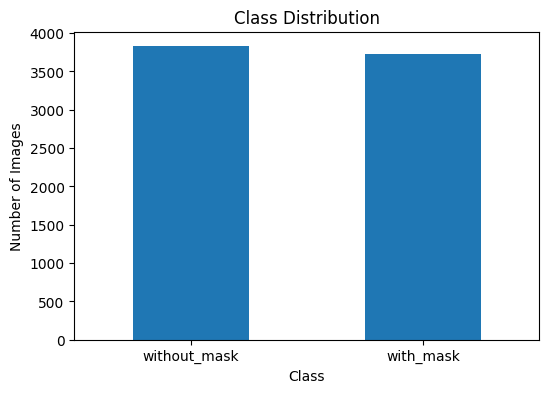

In [9]:
plt.figure(figsize=(6, 4))
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

## 4. Show a few sample images



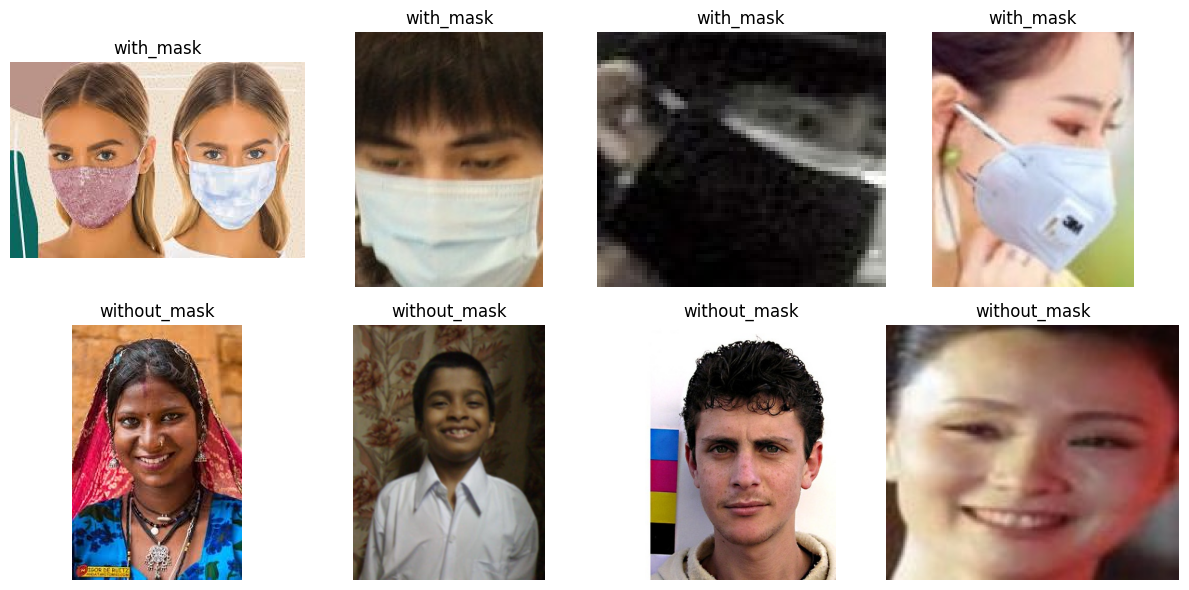

In [10]:
sample_df = df.groupby("label").sample(4, random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(12, 6))
for i, row in sample_df.iterrows():
    img = Image.open(row["filepath"]).convert("RGB")
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Train / validation / test split

- Train: 70%
- Validation: 15%
- Test: 15%



In [11]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (5287, 2)
Validation shape: (1133, 2)
Test shape: (1133, 2)


In [12]:
for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\n{name} distribution:")
    print(split_df["label"].value_counts())


Train distribution:
label
without_mask    2680
with_mask       2607
Name: count, dtype: int64

Validation distribution:
label
without_mask    574
with_mask       559
Name: count, dtype: int64

Test distribution:
label
without_mask    574
with_mask       559
Name: count, dtype: int64


## 6. Image preprocessing and augmentation



In [13]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)

val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 5287 validated image filenames belonging to 2 classes.
Found 1133 validated image filenames belonging to 2 classes.
Found 1133 validated image filenames belonging to 2 classes.
Class indices: {'with_mask': 0, 'without_mask': 1}


## 7. Build the CNN model



In [14]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Dropout(0.30),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.40),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,485,825 (9.48 MB)

 Trainable params: 2,485,825 (9.48 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Callbacks



In [15]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        "best_face_mask_cnn.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

## 9. Train the model



In [27]:
EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
 44/166 ━━━━━━━━━━━━━━━━━━━━ 24s 202ms/step - accuracy: 0.9341 - loss: 0.1801

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9382 - loss: 0.1665
Epoch 1: val_loss improved from 0.15711 to 0.14189, saving model to best_face_mask_cnn.keras

Epoch 1: finished saving model to best_face_mask_cnn.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 34s 202ms/step - accuracy: 0.9389 - loss: 0.1614 - val_accuracy: 0.9523 - val_loss: 0.1419 - learning_rate: 0.0010
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9436 - loss: 0.1511
Epoch 2: val_loss improved from 0.14189 to 0.12803, saving model to best_face_mask_cnn.keras

Epoch 2: finished saving model to best_face_mask_cnn.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 37s 223ms/step - accuracy: 0.9448 - loss: 0.1498 - val_accuracy: 0.9585 - val_loss: 0.1280 - learning_rate: 0.0010
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.9484 - loss: 0.1424
Epoch 3: val_loss did not improve from 0.12803
166/166 ━━━━━━━━━━━━━━━━━━━━ 42s 252ms/step - accuracy: 0.9470 - loss: 0.1480 - val_accuracy: 0.9550 - val

## 10. Plot training history

In [28]:
history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.938907,0.161356,0.952339,0.141887,0.001
1,0.944770,0.149812,0.958517,0.128030,0.001
2,0.947040,0.148046,0.954987,0.134193,0.001
3,0.952714,0.142430,0.970874,0.095192,0.001
4,0.953660,0.129351,0.962930,0.108628,0.001


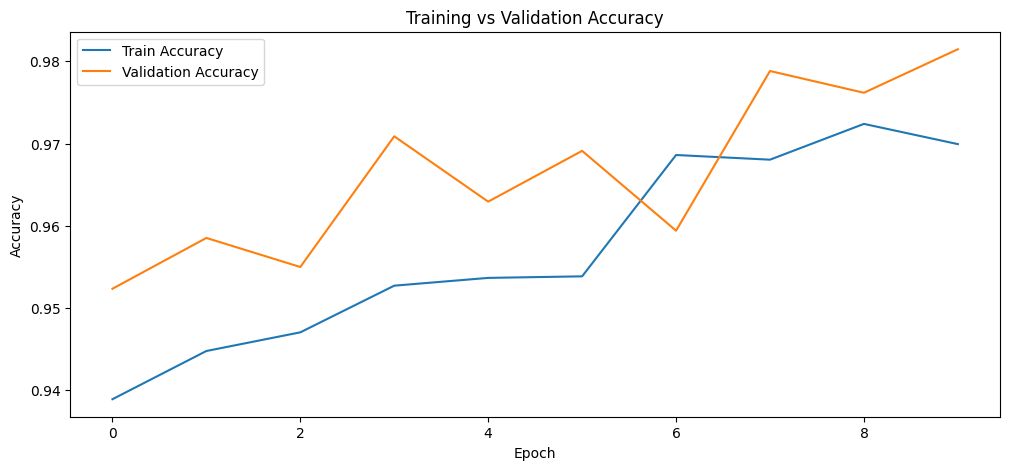

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

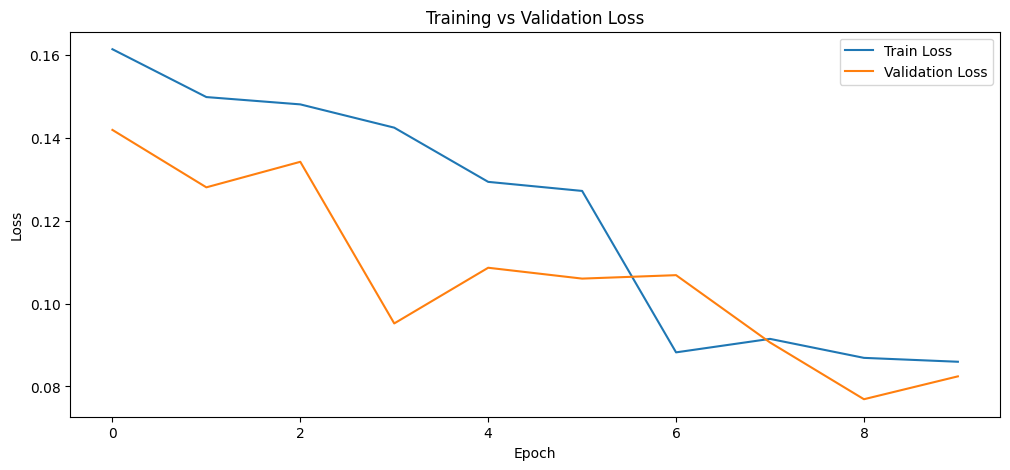

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 11. Evaluate on the test set

In [31]:
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9797 - loss: 0.0739
Test Loss: 0.0739
Test Accuracy: 0.9797


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step


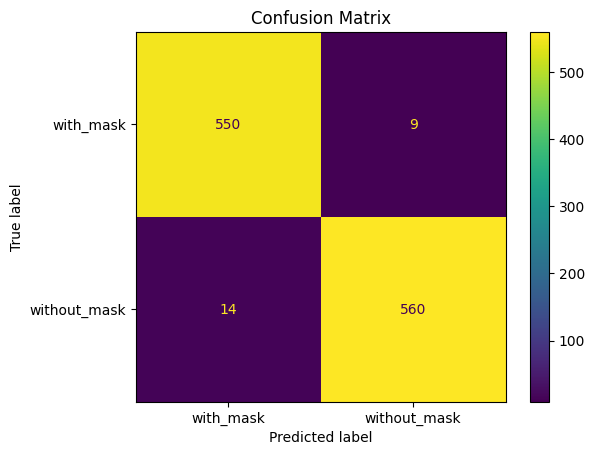

In [32]:
pred_probs = model.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype(int).ravel()
true_labels = test_generator.classes

cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_generator.class_indices.keys()))
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [33]:
print(classification_report(
    true_labels,
    pred_labels,
    target_names=list(test_generator.class_indices.keys())
))

              precision    recall  f1-score   support

   with_mask       0.98      0.98      0.98       559
without_mask       0.98      0.98      0.98       574

    accuracy                           0.98      1133
   macro avg       0.98      0.98      0.98      1133
weighted avg       0.98      0.98      0.98      1133



## 12. Try prediction on a single image


In [34]:
index_to_label = {v: k for k, v in train_generator.class_indices.items()}

def predict_single_image(image_path, model, image_size=IMG_SIZE):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(image_size)

    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prob = model.predict(img_array, verbose=0)[0][0]
    pred_class = 1 if prob > 0.5 else 0
    label = index_to_label[pred_class]

    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(image_path).convert("RGB"))
    plt.title(f"Prediction: {label}\nConfidence: {prob:.4f}")
    plt.axis("off")
    plt.show()

    return label, prob

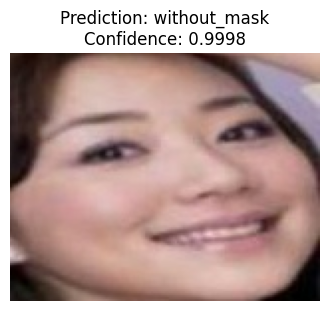

('without_mask', np.float32(0.9997708))

In [35]:
example_image = test_df.sample(1, random_state=SEED)["filepath"].iloc[0]
predict_single_image(example_image, model)

## 13. Save the trained model

In [36]:
model.save("face_mask_detection_final.keras")
print("Model saved successfully.")

Model saved successfully.


In [37]:
class_mapping = pd.DataFrame({
    "label": list(train_generator.class_indices.keys()),
    "index": list(train_generator.class_indices.values())
})
class_mapping.to_csv("class_mapping.csv", index=False)
class_mapping

,label,index
0,with_mask,0
1,without_mask,1


## GitHub Link Placeholder

`https://github.com/anshul55555/Face-Mask-Detection-.git`